In [18]:
from pathlib import Path
import csv
from collections import defaultdict
from statistics import mean, stdev

import matplotlib.pyplot as plt

# RUN_DIR_INPUT = "evaluation_results/snr_validation_20260604_183123"
# RUN_DIR_INPUT = "evaluation_results/snr_validation_20260605_082204"
RUN_DIR_INPUT = "evaluation_results/snr_validation_20260605_115034"



def resolve_run_dir(path_like):
    path = Path(path_like).expanduser()
    candidates = [path, Path.cwd() / path, Path.cwd().parent / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Run directory not found: {path_like}")


RUN_DIR = resolve_run_dir(RUN_DIR_INPUT)
SUMMARY_PATH = RUN_DIR / "summary.csv"

print(RUN_DIR)
print(SUMMARY_PATH)

/sps/l2it/tdonze/gb-source-counting/evaluation_results/snr_validation_20260605_115034
/sps/l2it/tdonze/gb-source-counting/evaluation_results/snr_validation_20260605_115034/summary.csv


In [19]:
def load_summary(summary_path):
    rows = []
    with summary_path.open(newline="") as handle:
        reader = csv.DictReader(handle)
        for raw in reader:
            if raw.get("dataset") not in {"snr_gap", "homogeneous"}:
                continue

            try:
                row = {
                    "dataset": raw["dataset"],
                    "target": float(raw["target"]),
                    "seed": int(float(raw["seed"])),
                    "macro_f1": float(raw["macro_f1"]),
                    "mae": float(raw["mae"]),
                    "n": int(float(raw.get("n") or 0)),
                }
            except (TypeError, ValueError, KeyError):
                # Utile si summary.csv est lu pendant qu'une evaluation l'ecrit encore.
                continue

            rows.append(row)
    return rows


rows = load_summary(SUMMARY_PATH)
if not rows:
    raise ValueError(f"No usable rows found in {SUMMARY_PATH}")

print(f"Loaded {len(rows)} rows")
print("Datasets:", sorted({row["dataset"] for row in rows}))
print("Seeds:", sorted({row["seed"] for row in rows}))

for dataset in ["snr_gap", "homogeneous"]:
    targets = sorted({row["target"] for row in rows if row["dataset"] == dataset})
    print(f"{dataset}: {len(targets)} targets -> {targets}")

Loaded 18 rows
Datasets: ['homogeneous', 'snr_gap']
Seeds: [42]
snr_gap: 8 targets -> [10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0]
homogeneous: 10 targets -> [10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 98.0]


In [20]:
def format_target(value):
    return int(value) if float(value).is_integer() else value


def grouped_stats(rows, dataset, metric):
    values_by_target = defaultdict(list)
    for row in rows:
        if row["dataset"] == dataset:
            values_by_target[row["target"]].append(row[metric])

    stats = []
    for target in sorted(values_by_target):
        values = values_by_target[target]
        stats.append(
            {
                "target": target,
                "mean": mean(values),
                "std": stdev(values) if len(values) > 1 else 0.0,
                "count": len(values),
            }
        )
    return stats


def seed_series(rows, dataset, metric):
    values_by_seed_target = defaultdict(list)
    for row in rows:
        if row["dataset"] == dataset:
            values_by_seed_target[(row["seed"], row["target"])].append(row[metric])

    series = defaultdict(list)
    for (seed, target), values in values_by_seed_target.items():
        series[seed].append((target, mean(values)))

    return {seed: sorted(points) for seed, points in series.items()}


def plot_metric(ax, rows, dataset, metric, title, ylabel, xlabel, color):
    stats = grouped_stats(rows, dataset, metric)
    if not stats:
        ax.text(0.5, 0.5, "No data yet", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        ax.set_axis_off()
        return

    x = [item["target"] for item in stats]
    y = [item["mean"] for item in stats]
    y_std = [item["std"] for item in stats]
    counts = [item["count"] for item in stats]

    per_seed = seed_series(rows, dataset, metric)
    if len(per_seed) > 1:
        for points in per_seed.values():
            ax.plot(
                [target for target, _ in points],
                [value for _, value in points],
                color="0.45",
                linewidth=0.9,
                marker=".",
                alpha=0.28,
            )

    ax.plot(x, y, color=color, linewidth=2.2, marker="o", label="mean")
    if any(count > 1 for count in counts):
        ax.fill_between(
            x,
            [value - err for value, err in zip(y, y_std)],
            [value + err for value, err in zip(y, y_std)],
            color=color,
            alpha=0.16,
            label="std over seeds",
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([format_target(value) for value in x])
    ax.grid(True, alpha=0.28)
    if metric == "macro_f1":
        ax.set_ylim(0.0, 1.0)
    ax.legend(loc="best")


try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

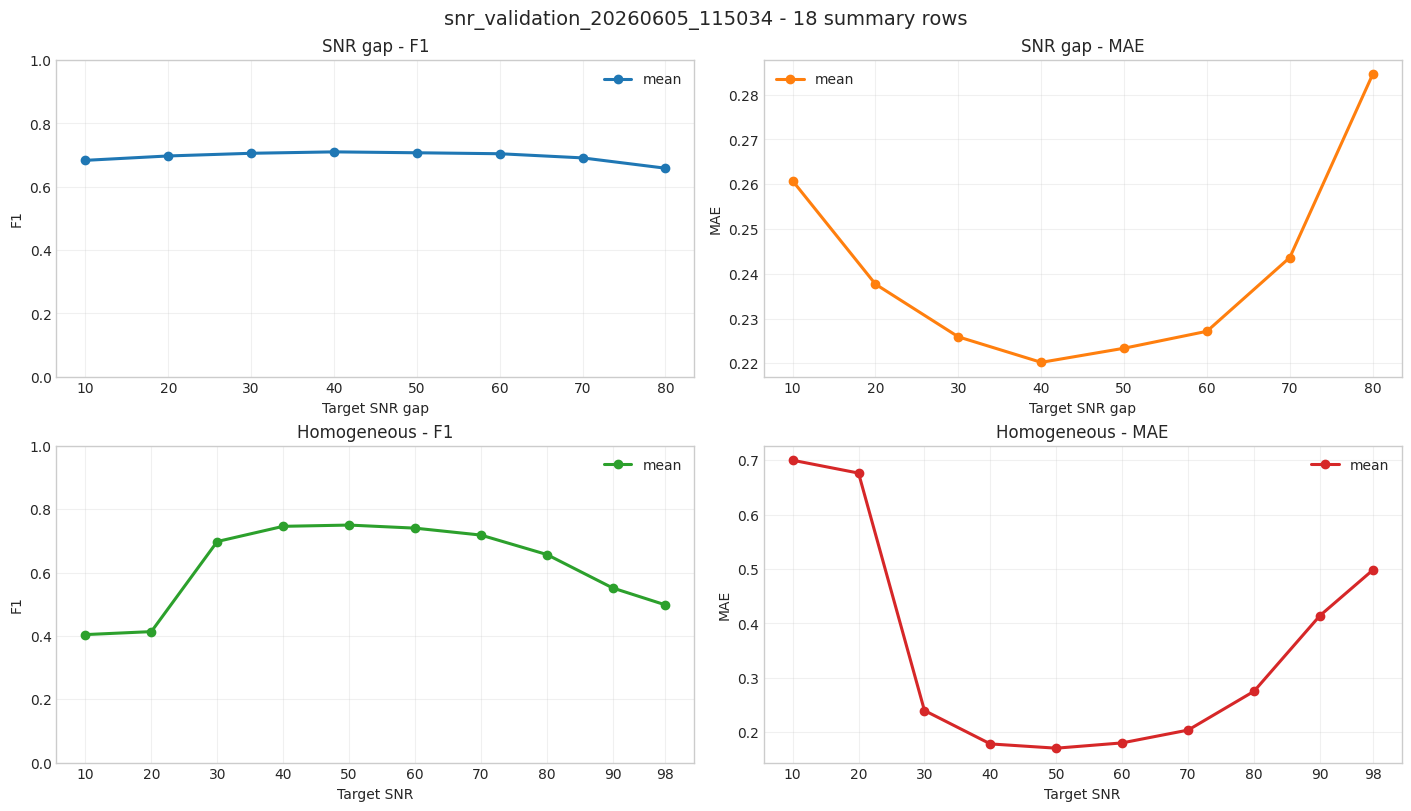

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

plot_metric(
    axes[0, 0], rows, "snr_gap", "macro_f1",
    "SNR gap - F1", "F1", "Target SNR gap", "tab:blue"
)
plot_metric(
    axes[0, 1], rows, "snr_gap", "mae",
    "SNR gap - MAE", "MAE", "Target SNR gap", "tab:orange"
)
plot_metric(
    axes[1, 0], rows, "homogeneous", "macro_f1",
    "Homogeneous - F1", "F1", "Target SNR", "tab:green"
)
plot_metric(
    axes[1, 1], rows, "homogeneous", "mae",
    "Homogeneous - MAE", "MAE", "Target SNR", "tab:red"
)

fig.suptitle(f"{RUN_DIR.name} - {len(rows)} summary rows", fontsize=14)
plt.show()